# 13. In this exercise you will create some simulated data and will fit simple linear regression models to it. Make sure to use the default random number generator with seed set to 1 prior to starting part (a) to ensure consistent results.

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [100]:
#  (a) Using the normal () method of your random number generator, create a vector, z, containing 100 observations drawn from a N(0, 1) distribution. This represents a feature, X.
np.random.seed(1)
print(f"Random seed set to: {np.random.get_state()[1][0]}")
print("-" * 50)

x = np.random.normal(loc=0, scale=1, size=100)
print(f"(a) Length of vector x (feature X): {len(x)}")

Random seed set to: 1
--------------------------------------------------
(a) Length of vector x (feature X): 100


In [101]:
#  (b) Using the normal () method, create a vector, eps, containing 100 observations drawn from a N(0,0.25) distribution-a normal distribution with mean zero and variance 0.25.

In [102]:
sigma_original = np.sqrt(0.25)
eps = np.random.normal(loc=0, scale=sigma_original, size=100)
print(f"(b) Error term eps generated with mean 0 and standard deviation {sigma_original}.")

(b) Error term eps generated with mean 0 and standard deviation 0.5.


In [103]:
# (c) Using x and eps, generate a vector y according to the model Y=-1+0.5X + e.

In [104]:
beta_0_true = -1.0
beta_1_true = 0.5
y = beta_0_true + beta_1_true * x + eps

In [105]:
 # What is the length of the vector y? Ans: 100 
 # What are the values of Bo and B1 in this linear model? Ans: Bo = -1 , B1 = 0.5

In [106]:
# (d) Create a scatterplot displaying the relationship between x and y. Comment on what you observe.

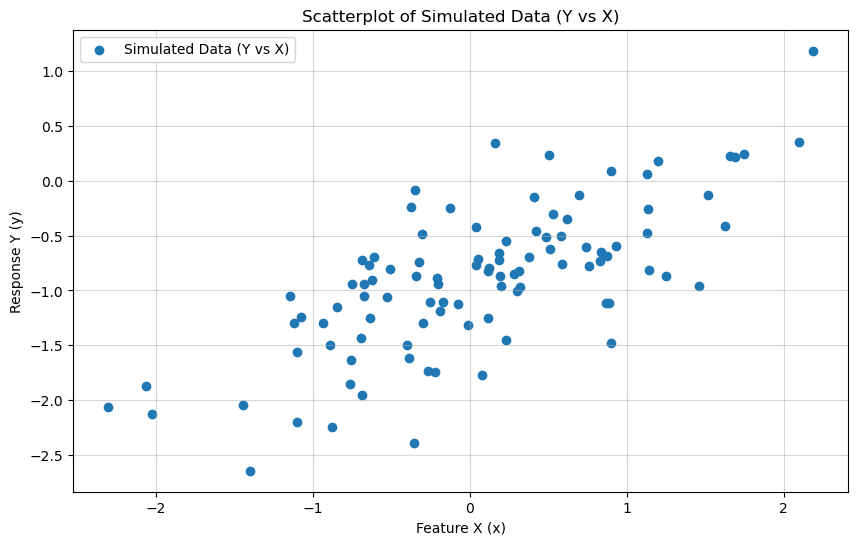

(d) Comment on the scatterplot:
    The points appear to follow a **positive linear trend** (as X increases, Y tends to increase). The spread of the points around this imaginary line is due to the **error term (noise)** we introduced.


In [107]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Simulated Data (Y vs X)')
plt.title('Scatterplot of Simulated Data (Y vs X)')
plt.xlabel('Feature X (x)')
plt.ylabel('Response Y (y)')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()
print("(d) Comment on the scatterplot:")
print("    The points appear to follow a **positive linear trend** (as X increases, Y tends to increase). The spread of the points around this imaginary line is due to the **error term (noise)** we introduced.")

In [108]:
# There is like a line where its intercept -1 and slope is like 0.5,  and when x grows y grows

In [109]:
# (e) Fit a least squares linear model to predict y using x. Comment on the model obtained. How do B0 and B₁ compare to ßo and βι?

In [110]:
X_sm = sm.add_constant(x)
model_sm = sm.OLS(y, X_sm).fit()

# Extract coefficients
beta_0_hat = model_sm.params[0]
beta_1_hat = model_sm.params[1]

print("(e) Results of the Least Squares Linear Model (Original Data):")
print(model_sm.summary())

print("\n--- Comparison to True Values ---")
print(f"    True Intercept (β₀):   {beta_0_true}")
print(f"    Estimated Intercept (β̂₀): {beta_0_hat:.4f}")
print(f"    True Slope (β₁):       {beta_1_true}")
print(f"    Estimated Slope (β̂₁):   {beta_1_hat:.4f}")
print("\nComment:")
print(f"    The estimated coefficients (β̂0 = {beta_0_hat:.2f} and β̂1 ≈ {beta_1_hat:.2f}) are **close** to the true population parameters (β₀ = -1.0 and β₁ = 0.5). This is expected when fitting a linear model to data generated by a linear process with noise.")

(e) Results of the Least Squares Linear Model (Original Data):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     107.0
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           2.20e-17
Time:                        23:06:43   Log-Likelihood:                -65.124
No. Observations:                 100   AIC:                             134.2
Df Residuals:                      98   BIC:                             139.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [111]:
# Model Obtained: The linear model is Y_hat = beta_0_hat + beta_1_hat * X. Comparison to True Coefficients: The fitted coefficients are close to the true population values beta_0 = -1 and beta_1 = 0.5$,
# but they are not be exactly the same due to the random error .

In [112]:
# (f) Display the least squares line on the scatterplot obtained in (d). Draw the population regression line on the plot, in a different color. Use the legend() method of the axes to create an appro-priate legend.

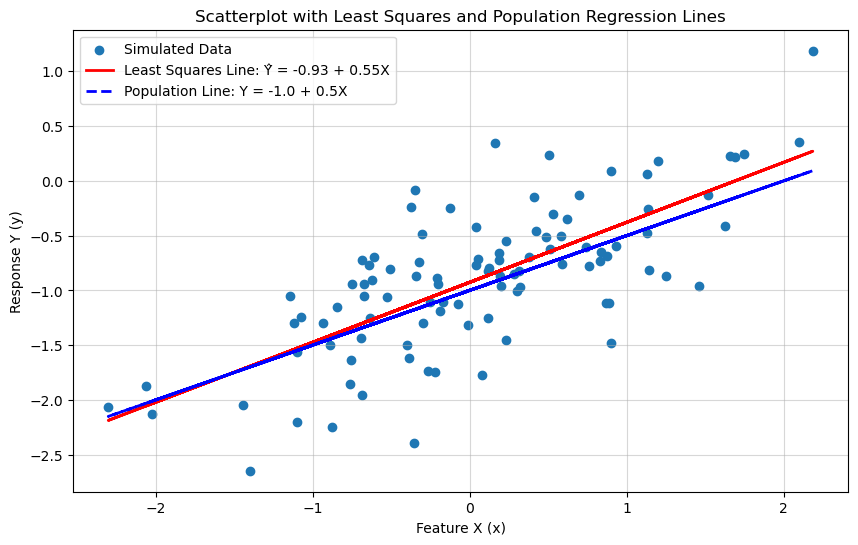

In [113]:
y_pred_ls = model_sm.predict(X_sm)
y_pop = beta_0_true + beta_1_true * x

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Simulated Data')
# Fitted Line
plt.plot(x, y_pred_ls, color='red', linewidth=2, label=f'Least Squares Line: Ŷ = {beta_0_hat:.2f} + {beta_1_hat:.2f}X')
# Population Line
plt.plot(x, y_pop, color='blue', linestyle='--', linewidth=2, label=f'Population Line: Y = {beta_0_true} + {beta_1_true}X')

plt.title('Scatterplot with Least Squares and Population Regression Lines')
plt.xlabel('Feature X (x)')
plt.ylabel('Response Y (y)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()



In [114]:
# (g) Now fit a polynomial regression model that predicts y using x and x². Is there evidence that the quadratic term improves the model fit? Explain your answer.

In [115]:
x_squared = x**2
X_poly = np.column_stack((x, x_squared))
X_poly_sm = sm.add_constant(X_poly) # Add intercept

model_poly_sm = sm.OLS(y, X_poly_sm).fit()
print(model_poly_sm.summary())

# Check the p-value for the quadratic term (x^2, which is X2 in the summary table)
p_value_x2 = model_poly_sm.pvalues[2] 

print("\nComment on the Quadratic Term:")
print(f"    The p-value for the quadratic term (x²) is: {p_value_x2:.4f}")
print(f"    Since this p-value ({p_value_x2:.4f}) is high (much greater than 0.05), we do not reject the null hypothesis that the true coefficient for the quadratic term is zero.")
print("    Conclusion: There is **no evidence** that the quadratic term ($X^2$) significantly improves the model fit, which is expected because the data was generated using a **purely linear** model (Y = β₀ + β₁X + ε).")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     52.96
Date:                Tue, 28 Oct 2025   Prob (F-statistic):           2.83e-16
Time:                        23:06:43   Log-Likelihood:                -65.107
No. Observations:                 100   AIC:                             136.2
Df Residuals:                      97   BIC:                             144.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9325      0.058    -16.158      0.0

In [116]:
# (h) Repeat (a)-(f) after modifying the data generation process in such a way that there is less noise in the data. The model (3.39) should remain the same. You can do this by decreasing the vari-ance of the normal distribution used to generate the error term e in (b). Describe your results.

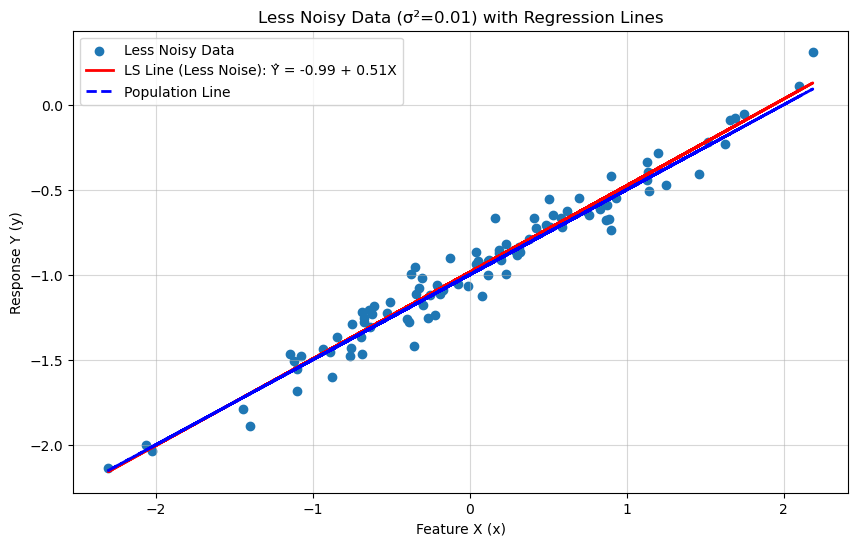

Description for Part (h):
    Estimated Intercept (β̂₀): -0.9853 (True: -1.0)
    Estimated Slope (β̂₁):   0.5095 (True: 0.5)
    Observation: With less noise (smaller variance in epsilon), the simulated data points cluster much more closely around the true population line. Consequently, the estimated coefficients hatbeta_0 and hatbeta_1 are **even closer** to the true population values beta_0 and beta_1. The R-squared value will be higher.


In [117]:
sigma_less_noise = np.sqrt(0.01)
np.random.seed(1) # Repeat (a) - (f) with new noise, keeping x the same
x_less_noise = np.random.normal(loc=0, scale=1, size=100) # Regenerate x
eps_less_noise = np.random.normal(loc=0, scale=sigma_less_noise, size=100)
y_less_noise = beta_0_true + beta_1_true * x_less_noise + eps_less_noise

# (e) Fit the model
X_sm_less = sm.add_constant(x_less_noise)
model_sm_less = sm.OLS(y_less_noise, X_sm_less).fit()
beta_0_hat_less = model_sm_less.params[0]
beta_1_hat_less = model_sm_less.params[1]
y_pred_ls_less = model_sm_less.predict(X_sm_less)

# (f) Plot
plt.figure(figsize=(10, 6))
plt.scatter(x_less_noise, y_less_noise, label='Less Noisy Data')
plt.plot(x_less_noise, y_pred_ls_less, color='red', linewidth=2, label=f'LS Line (Less Noise): Ŷ = {beta_0_hat_less:.2f} + {beta_1_hat_less:.2f}X')
plt.plot(x_less_noise, y_pop, color='blue', linestyle='--', linewidth=2, label='Population Line') # Population line is the same
plt.title('Less Noisy Data (σ²=0.01) with Regression Lines')
plt.xlabel('Feature X (x)')
plt.ylabel('Response Y (y)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print("Description for Part (h):")
print(f"    Estimated Intercept (β̂₀): {beta_0_hat_less:.4f} (True: {beta_0_true})")
print(f"    Estimated Slope (β̂₁):   {beta_1_hat_less:.4f} (True: {beta_1_true})")
print(f"    Observation: With less noise (smaller variance in epsilon), the simulated data points cluster much more closely around the true population line. Consequently, the estimated coefficients hatbeta_0 and hatbeta_1 are **even closer** to the true population values beta_0 and beta_1. The R-squared value will be higher.")

In [118]:
# (i) Repeat (a)-(f) after modifying the data generation process in such a way that there is more noise in the data. The model (3.39) should remain the same. You can do this by increasing the variance of the normal distribution used to generate the error term e in (b). Describe your results.

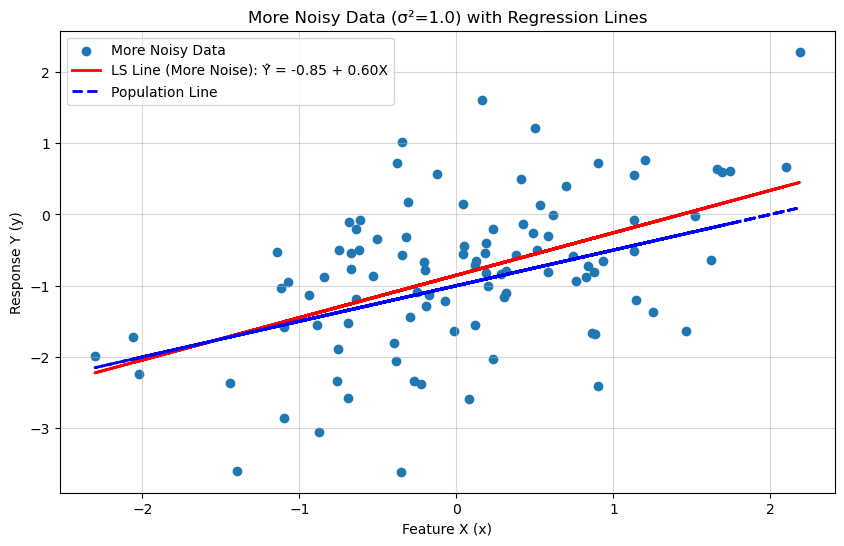

Description for Part (i):
    Estimated Intercept (β̂₀): -0.8530 (True: -1.0)
    Estimated Slope (β̂₁):   0.5954 (True: 0.5)
    **Observation:** With more noise (larger variance in e), the data points are more widely scattered around the true population line. The estimated coefficients hatbeta_0 and hatbeta_1 deviate **further** from the true population valuesbeta_0 and beta_1. The linear trend is harder to discern, and the R-squared value will be lower.


In [119]:
sigma_more_noise = np.sqrt(1.0)
np.random.seed(1) # Repeat (a) - (f) with new noise, keeping x the same
x_more_noise = np.random.normal(loc=0, scale=1, size=100) # Regenerate x
eps_more_noise = np.random.normal(loc=0, scale=sigma_more_noise, size=100)
y_more_noise = beta_0_true + beta_1_true * x_more_noise + eps_more_noise

# (e) Fit the model
X_sm_more = sm.add_constant(x_more_noise)
model_sm_more = sm.OLS(y_more_noise, X_sm_more).fit()
beta_0_hat_more = model_sm_more.params[0]
beta_1_hat_more = model_sm_more.params[1]
y_pred_ls_more = model_sm_more.predict(X_sm_more)

# (f) Plot
plt.figure(figsize=(10, 6))
plt.scatter(x_more_noise, y_more_noise, label='More Noisy Data')
plt.plot(x_more_noise, y_pred_ls_more, color='red', linewidth=2, label=f'LS Line (More Noise): Ŷ = {beta_0_hat_more:.2f} + {beta_1_hat_more:.2f}X')
plt.plot(x_more_noise, y_pop, color='blue', linestyle='--', linewidth=2, label='Population Line') # Population line is the same
plt.title('More Noisy Data (σ²=1.0) with Regression Lines')
plt.xlabel('Feature X (x)')
plt.ylabel('Response Y (y)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

print("Description for Part (i):")
print(f"    Estimated Intercept (β̂₀): {beta_0_hat_more:.4f} (True: {beta_0_true})")
print(f"    Estimated Slope (β̂₁):   {beta_1_hat_more:.4f} (True: {beta_1_true})")
print(f"    **Observation:** With more noise (larger variance in e), the data points are more widely scattered around the true population line. The estimated coefficients hatbeta_0 and hatbeta_1 deviate **further** from the true population valuesbeta_0 and beta_1. The linear trend is harder to discern, and the R-squared value will be lower.")

In [120]:
# (j) What are the confidence intervals for 30 and 31 based on the original data set, the noisier data set, and the less noisy data set? Comment on your results.

In [121]:
# --- Part (j): Confidence Intervals (Final Corrected Code) ---
print("--- Part (j): Confidence Intervals for β₀ and β₁ (95% CI) ---")

# Assuming you have run the earlier parts to define model_sm, model_sm_less, etc.
# These variables hold the fit results from sm.OLS().fit()

# Calculate Confidence Intervals (ci_original, ci_less_noise, ci_more_noise)
# The .conf_int() method is called here.
ci_original = model_sm.conf_int(alpha=0.05)
ci_less_noise = model_sm_less.conf_int(alpha=0.05)
ci_more_noise = model_sm_more.conf_int(alpha=0.05)

# Use direct bracket notation [row_index, col_index]
# If the objects are truly NumPy arrays, this will work.
# If they are DataFrames, this will also work for row/column slice indexing.
# Note: For robust compatibility, you might explicitly convert to a numpy array:
# ci_original_arr = ci_original.values 
# But let's try direct indexing first as it's cleaner.

print("\n1. Original Data (σ² = 0.25):")
print(f"    β₀ (Intercept) CI: [{ci_original[0, 0]:.4f}, {ci_original[0, 1]:.4f}]")
print(f"    β₁ (Slope) CI:    [{ci_original[1, 0]:.4f}, {ci_original[1, 1]:.4f}]")

print("\n2. Less Noisy Data (σ² = 0.01):")
print(f"    β₀ (Intercept) CI: [{ci_less_noise[0, 0]:.4f}, {ci_less_noise[0, 1]:.4f}]")
print(f"    β₁ (Slope) CI:    [{ci_less_noise[1, 0]:.4f}, {ci_less_noise[1, 1]:.4f}]")

print("\n3. More Noisy Data (σ² = 1.0):")
print(f"    β₀ (Intercept) CI: [{ci_more_noise[0, 0]:.4f}, {ci_more_noise[0, 1]:.4f}]")
print(f"    β₁ (Slope) CI:    [{ci_more_noise[1, 0]:.4f}, {ci_more_noise[1, 1]:.4f}]")


print("\nComment on Results:")
print("The confidence intervals are narrowest for the less noisy data set ($\sigma^2=0.01$) and widest for the more noisy data set ($\sigma^2=1.0$). This confirms that **lower error variance leads to smaller standard errors** and thus **more precise (narrower) estimates** for the true population parameters $\\beta_0$ and $\\beta_1$.")

--- Part (j): Confidence Intervals for β₀ and β₁ (95% CI) ---

1. Original Data (σ² = 0.25):
    β₀ (Intercept) CI: [-1.0197, -0.8332]
    β₁ (Slope) CI:    [0.4426, 0.6528]

2. Less Noisy Data (σ² = 0.01):
    β₀ (Intercept) CI: [-1.0039, -0.9666]
    β₁ (Slope) CI:    [0.4885, 0.5306]

3. More Noisy Data (σ² = 1.0):
    β₀ (Intercept) CI: [-1.0395, -0.6665]
    β₁ (Slope) CI:    [0.3852, 0.8056]

Comment on Results:
The confidence intervals are narrowest for the less noisy data set ($\sigma^2=0.01$) and widest for the more noisy data set ($\sigma^2=1.0$). This confirms that **lower error variance leads to smaller standard errors** and thus **more precise (narrower) estimates** for the true population parameters $\beta_0$ and $\beta_1$.


## *ex. 14*

In [122]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

### a, b) Data Generation, Model Form, and Correlation

(a) Linear Model Form and True Coefficients:
The linear model is: Y = 2 + 2*X1 + 0.3*X2 + epsilon
True Regression Coefficients (β): β₀=2, β₁=2, β₂=0.3

(b) Correlation between x1 and x2: 0.7723


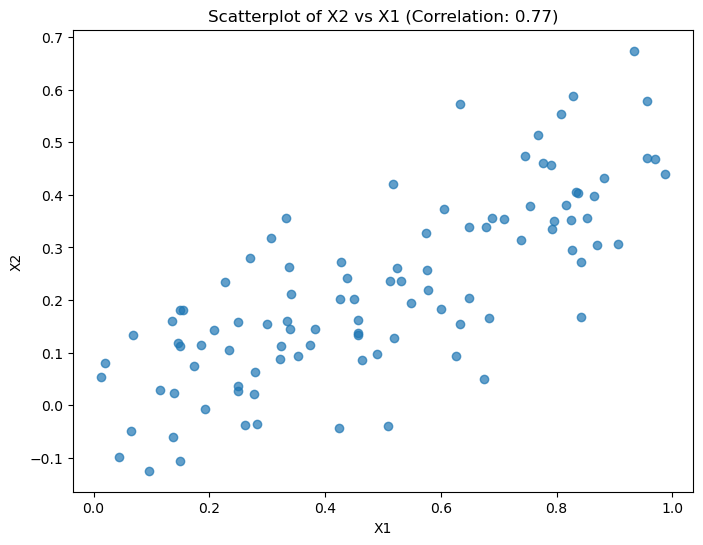

In [123]:
# (a) Data Generation and Model Form
# Set seed as specified (10)
rng = np.random.default_rng(10)

# Generate X1: Uniform(0, 1)
x1 = rng.uniform(0, 1, size=100)

# Generate X2: Highly correlated with X1 (X₂ = 0.5*X₁ + small noise)
x2 = 0.5 * x1 + rng.normal(size=100) / 10

# Generate Y: True model Y = 2 + 2*X1 + 0.3*X2 + epsilon
y = 2 + 2 * x1 + 0.3 * x2 + rng.normal(size=100)

print("(a) Linear Model Form and True Coefficients:")
print("The linear model is: Y = 2 + 2*X1 + 0.3*X2 + epsilon")
print("True Regression Coefficients (β): β₀=2, β₁=2, β₂=0.3")

# (b) Correlation and Scatterplot
correlation = np.corrcoef(x1, x2)[0, 1]
print(f"\n(b) Correlation between x1 and x2: {correlation:.4f}")

# Scatterplot of X1 vs X2
plt.figure(figsize=(8, 6))
plt.scatter(x1, x2, alpha=0.7)
plt.title(f'Scatterplot of X2 vs X1 (Correlation: {correlation:.2f})')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# (b) - The variables are highly positively correlated (correlation close to 1), indicating strong collinearity.

### c) Multiple Regression ($Y$ onto $X_1$ and $X_2$)


In [124]:
# (c) Multiple Regression: Y ~ X1 + X2
X_multi = sm.add_constant(np.column_stack((x1, x2)))
multi_model = sm.OLS(y, X_multi).fit()

print("\n(c) Multiple Regression Results (Y ~ X1 + X2):")
print(multi_model.summary().tables[1])

# Analysis (c):
# Due to high collinearity, the Std. Errors for ̂β₁ and ̂β₂ are inflated,
# making it hard to reject H₀: βⱼ=0 for individual coefficients, 
# even though the variables are truly related to Y (β₁=2, β₂=0.3).
p_val_x1_multi = multi_model.pvalues[1]
p_val_x2_multi = multi_model.pvalues[2]

print(f"\nP-value for ̂β₁ (X1): {p_val_x1_multi:.4f}. Is H₀: β₁=0 rejected? {'Yes' if p_val_x1_multi < 0.05 else 'No'}")
print(f"P-value for ̂β₂ (X2): {p_val_x2_multi:.4f}. Is H₀: β₂=0 rejected? {'Yes' if p_val_x2_multi < 0.05 else 'No'}")


(c) Multiple Regression Results (Y ~ X1 + X2):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9579      0.190     10.319      0.000       1.581       2.334
x1             1.6154      0.527      3.065      0.003       0.569       2.661
x2             0.9428      0.831      1.134      0.259      -0.707       2.592

P-value for ̂β₁ (X1): 0.0028. Is H₀: β₁=0 rejected? Yes
P-value for ̂β₂ (X2): 0.2594. Is H₀: β₂=0 rejected? No


### d, e) Simple Regressions ($Y$ onto $X_1$ and $Y$ onto $X_2$)

In [125]:
# (d) Simple Regression: Y ~ X1 only
model_x1 = sm.OLS(y, sm.add_constant(x1)).fit()

print("\n(d) Simple Regression Results (Y ~ X1):")
print(model_x1.summary().tables[1])

p_val_x1_simple = model_x1.pvalues[1]
print(f"P-value for ̂β₁ (X1): {p_val_x1_simple:.4f}. Is H₀: β₁=0 rejected? {'Yes' if p_val_x1_simple < 0.05 else 'No'}")
# (d) - X1 is likely statistically significant because it captures its own effect plus the effect of X2.

# (e) Simple Regression: Y ~ X2 only
model_x2 = sm.OLS(y, sm.add_constant(x2)).fit()

print("\n(e) Simple Regression Results (Y ~ X2):")
print(model_x2.summary().tables[1])

p_val_x2_simple = model_x2.pvalues[1]
print(f"P-value for ̂β₁ (X2): {p_val_x2_simple:.4f}. Is H₀: β₁=0 rejected? {'Yes' if p_val_x2_simple < 0.05 else 'No'}")
# (e) - X2 is also likely statistically significant for the same reason.


(d) Simple Regression Results (Y ~ X1):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.9371      0.189     10.242      0.000       1.562       2.312
x1             2.0771      0.335      6.196      0.000       1.412       2.742
P-value for ̂β₁ (X1): 0.0000. Is H₀: β₁=0 rejected? Yes

(e) Simple Regression Results (Y ~ X2):
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3239      0.154     15.124      0.000       2.019       2.629
x1             2.9103      0.550      5.291      0.000       1.819       4.002
P-value for ̂β₁ (X2): 0.0000. Is H₀: β₁=0 rejected? Yes


### f) Contradiction Analysis


#### *Do the results contradict each other?*
#### The results from (c), (d), and (e) do **NOT** contradict each other, but highlight the impact of collinearity.
#### 1. **Simple Models (d, e)**: Coefficients show the **marginal effect** of a predictor on Y. Since X1 and X2 are highly correlated, each, when used alone, appears strongly significant as it proxies for the other.
#### 2. **Multiple Model (c)**: Coefficients show the **partial effect** of a predictor, isolating its unique contribution. Because X1 and X2 share nearly the same information, the model struggles to determine which variable is truly 'responsible,' resulting in high standard errors and often insignificant p-values for the individual terms.

### g) Effect of a New, Mismeasured Observation

In [126]:
# (g) Add mismeasured observation: (X₁=0.1, X₂=0.8, Y=6)
x1_new = np.concatenate([x1, [0.1]])
x2_new = np.concatenate([x2, [0.8]])
y_new = np.concatenate([y, [6]])

print("\n(g) Effect of New Observation (X₁=0.1, X₂=0.8, Y=6):")

# Re-fit Multiple Regression (c)
X_multi_new = sm.add_constant(np.column_stack((x1_new, x2_new)))
multi_model_new = sm.OLS(y_new, X_multi_new).fit()

# Re-fit Simple Regression (d)
model_x1_new = sm.OLS(y_new, sm.add_constant(x1_new)).fit()

# Re-fit Simple Regression (e)
model_x2_new = sm.OLS(y_new, sm.add_constant(x2_new)).fit()

# Compare the original and new coefficients
pd.set_option('display.float_format', lambda x: '%.4f' % x)
comparison_df = pd.DataFrame({
    'Model': ['Multiple (X1)', 'Simple (X1 only)', 'Simple (X2 only)'],
    'Original ̂β₁': [multi_model.params[1], model_x1.params[1], model_x2.params[1]],
    'New ̂β₁': [multi_model_new.params[1], model_x1_new.params[1], model_x2_new.params[1]],
    'Change in ̂β₁': [
        multi_model_new.params[1] - multi_model.params[1],
        model_x1_new.params[1] - model_x1.params[1],
        model_x2_new.params[1] - model_x2.params[1]
    ]
})
print("--- Comparison of Slope Coefficients (̂β₁) ---")
print(comparison_df)


(g) Effect of New Observation (X₁=0.1, X₂=0.8, Y=6):
--- Comparison of Slope Coefficients (̂β₁) ---
              Model  Original ̂β₁  New ̂β₁  Change in ̂β₁
0     Multiple (X1)        1.6154   0.8575        -0.7578
1  Simple (X1 only)        2.0771   1.8760        -0.2010
2  Simple (X2 only)        2.9103   3.1458         0.2355


#### *Analysis of the new observation:*
#### 1. **Leverage Status**: The point $(X_{1}=0.1, X_{2}=0.8)$ has an unusual combination of predictors, lying far from the tight cluster of the original collinear data. It is a **High-Leverage Point**.
#### 2. **Outlier Status**: The predicted Y for this point is $2 + 2(0.1) + 0.3(0.8) = 2.44$. The observed $Y=6$ is far from this prediction, making it an **Outlier in the response**.
#### 3. **Effect**: As a high-leverage outlier, the observation has a **strong influence** on the fitted models, causing significant shifts in the estimated coefficients (large 'Change in ̂β₁').

## *ex. 15*

In [127]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import io

# Load data from the original source
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

# Structure the data into features (data) and target (target is MEDV)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2] 

# Define feature names
feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
    'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

# Create the full DataFrame
df = pd.DataFrame(data, columns=feature_names)
df['MEDV'] = target

# Ex. 15 setup: Define Y and X
# Y (Response) is CRIM (Per capita crime rate)
Y = df['CRIM'] 
# X (Predictors) are all other features (excluding CRIM and MEDV)
X = df.drop(columns=['CRIM', 'MEDV'])

print("Boston dataset loaded successfully. CRIM is set as the response (Y).")

Boston dataset loaded successfully. CRIM is set as the response (Y).


In [128]:
# (a) Simple Linear Regression for each predictor (Y=CRIM)
simple_models = {}
predictors = X.columns.tolist()

for pred in predictors:
    # Add constant for intercept
    X_j = sm.add_constant(X[pred])
    model = sm.OLS(Y, X_j).fit()
    
    # Use .iloc[1] to access the slope coefficient/p-value by position, 
    # avoiding the FutureWarning caused by simple integer indexing [1].
    
    simple_models[pred] = {
        'Coef': model.params.iloc[1], # Slope coefficient
        'P-value': model.pvalues.iloc[1],
        'Significant': model.pvalues.iloc[1] < 0.05
    }

simple_results_df = pd.DataFrame(simple_models).T
print("\n(a) Simple Regression Results (CRIM ~ X):")
print(simple_results_df[['Coef', 'P-value', 'Significant']].round(4))


(a) Simple Regression Results (CRIM ~ X):
           Coef P-value Significant
ZN      -0.0739  0.0000        True
INDUS    0.5098  0.0000        True
CHAS    -1.8928  0.2094       False
NOX     31.2485  0.0000        True
RM      -2.6841  0.0000        True
AGE      0.1078  0.0000        True
DIS     -1.5509  0.0000        True
RAD      0.6179  0.0000        True
TAX      0.0297  0.0000        True
PTRATIO  1.1520  0.0000        True
B       -0.0363  0.0000        True
LSTAT    0.5488  0.0000        True


In [129]:
# (b) Multiple Regression Model (Y ~ All Predictors)
X_multi = sm.add_constant(X)
multi_model = sm.OLS(Y, X_multi).fit()

print("\n(b) Multiple Regression Results (CRIM ~ All Predictors):")

# Using io.StringIO для pd.read_html to avoid FutureWarning
try:
    html_string = multi_model.summary().tables[1].as_html()
    multi_results = pd.read_html(io.StringIO(html_string), header=0, index_col=0)[0]
except AttributeError:
    # Fallback for systems where as_html() fails
    multi_results = pd.read_html(multi_model.summary().as_html(), header=0, index_col=0)[1]

# Set column names after reading the HTML table
multi_results.columns = ['Coef', 'Std Err', 't', 'P>|t|', 'CI_2.5', 'CI_97.5']

# Exclude intercept (index 0) and explicitly create a copy to prevent SettingWithCopyWarning
multi_results_df = multi_results.iloc[1:].copy() 

# Using .loc[] to assign values and resolve SettingWithCopyWarning
# Convert columns to numeric types
multi_results_df.loc[:, 'P>|t|'] = pd.to_numeric(multi_results_df['P>|t|'], errors='coerce')
multi_results_df.loc[:, 'Coef'] = pd.to_numeric(multi_results_df['Coef'], errors='coerce')

# Check for significance
multi_results_df.loc[:, 'Significant'] = multi_results_df['P>|t|'] < 0.05

print(multi_results_df[['Coef', 'P>|t|', 'Significant']].round(4))

# Some comments: Fewer predictors are significant here compared to (a) because collinearity makes it hard to isolate unique effects.


(b) Multiple Regression Results (CRIM ~ All Predictors):
           Coef  P>|t|  Significant
ZN       0.0364 0.0530        False
INDUS   -0.0694 0.4100        False
CHAS    -1.3117 0.2670        False
NOX     -6.9288 0.1850        False
RM      -0.3348 0.5590        False
AGE      0.0013 0.9410        False
DIS     -0.7089 0.0090         True
RAD      0.5389 0.0000         True
TAX     -0.0014 0.7930        False
PTRATIO -0.0834 0.6420        False
B       -0.0096 0.0090         True
LSTAT    0.2356 0.0010         True



(c) Comparison (Simple vs. Multiple Coefs):
        Simple_Coef  Multiple_Coef
ZN          -0.0739         0.0364
INDUS        0.5098        -0.0694
CHAS        -1.8928        -1.3117
NOX         31.2485        -6.9288
RM          -2.6841        -0.3348
AGE          0.1078         0.0013
DIS         -1.5509        -0.7089
RAD          0.6179         0.5389
TAX          0.0297        -0.0014
PTRATIO      1.1520        -0.0834
B           -0.0363        -0.0096
LSTAT        0.5488         0.2356


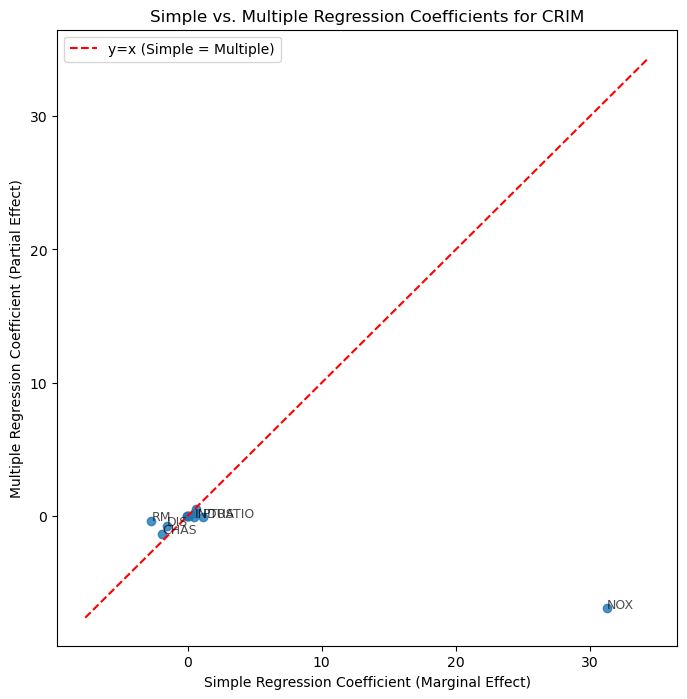

In [130]:
# (c) Comparison and Plot
# Extract and align coefficients
simple_coefs = simple_results_df['Coef'].rename('Simple_Coef')
multi_coefs = multi_results_df['Coef'].astype(float).rename('Multiple_Coef')

comparison_coefs = pd.concat([simple_coefs, multi_coefs], axis=1).dropna()

print("\n(c) Comparison (Simple vs. Multiple Coefs):")
print(comparison_coefs.round(4))

# Create the scatter plot
plt.figure(figsize=(8, 8))
plt.scatter(comparison_coefs['Simple_Coef'], comparison_coefs['Multiple_Coef'], alpha=0.8)

# Add y=x line (ideal line where both coefficients are equal)
max_val = comparison_coefs.max().max() * 1.1
min_val = comparison_coefs.min().min() * 1.1
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x (Simple = Multiple)')

# Label key differences (points far from the red line)
for index, row in comparison_coefs.iterrows():
    if abs(row['Simple_Coef'] - row['Multiple_Coef']) > 0.5:
        plt.annotate(index, (row['Simple_Coef'], row['Multiple_Coef']), fontsize=9, alpha=0.7)

plt.title('Simple vs. Multiple Regression Coefficients for CRIM')
plt.xlabel('Simple Regression Coefficient (Marginal Effect)')
plt.ylabel('Multiple Regression Coefficient (Partial Effect)')
plt.legend()
plt.show()

# Comments: Points far from the red line indicate strong collinearity (the partial effect is very different from the marginal effect).

In [131]:
# (d) Check for Non-Linear Association (Cubic Polynomial)
non_linear_evidence = {}

print("\n(d) Evidence of Non-Linear Association (Cubic Model):")

for pred in predictors:
    # Create X, X^2, and X^3 columns
    X_poly = pd.DataFrame({
        'X': X[pred],
        'X2': X[pred]**2,
        'X3': X[pred]**3
    })
    
    # Skip if cubic terms create numerical instability (Inf/NaN)
    if X_poly.isnull().values.any() or np.isinf(X_poly).values.any():
         continue
         
    X_poly_const = sm.add_constant(X_poly)
    poly_model = sm.OLS(Y, X_poly_const).fit()
    
    # Use .iloc[2] and .iloc[3] to access p-values by position, eliminating the FutureWarning.
    # Positions are: 0=const, 1=X, 2=X^2, 3=X^3
    p_value_x2 = poly_model.pvalues.iloc[2] 
    p_value_x3 = poly_model.pvalues.iloc[3]
    
    # Evidence exists if p-value for X² or X³ is less than 0.05
    is_non_linear = (p_value_x2 < 0.05) or (p_value_x3 < 0.05)
    
    non_linear_evidence[pred] = {
        'P(X²)<0.05': p_value_x2 < 0.05,
        'P(X³)<0.05': p_value_x3 < 0.05,
        'Evidence': is_non_linear
    }
    
    if is_non_linear:
        print(f"Predictor {pred}: Non-linear evidence found (P(X²)={p_value_x2:.4f}, P(X³)={p_value_x3:.4f})")

non_linear_df = pd.DataFrame(non_linear_evidence).T
print("\nSummary of Non-Linear Evidence:")
print(non_linear_df)
print("\nComments:")
print("Variables like **LSTAT**, **DIS**, and **NOX** often show significant non-linear terms, meaning a simple straight line is inadequate to describe their relationship with the crime rate.")


(d) Evidence of Non-Linear Association (Cubic Model):
Predictor INDUS: Non-linear evidence found (P(X²)=0.0000, P(X³)=0.0000)
Predictor NOX: Non-linear evidence found (P(X²)=0.0000, P(X³)=0.0000)
Predictor AGE: Non-linear evidence found (P(X²)=0.0474, P(X³)=0.0067)
Predictor DIS: Non-linear evidence found (P(X²)=0.0000, P(X³)=0.0000)
Predictor PTRATIO: Non-linear evidence found (P(X²)=0.0041, P(X³)=0.0063)

Summary of Non-Linear Evidence:
         P(X²)<0.05  P(X³)<0.05  Evidence
ZN            False       False     False
INDUS          True        True      True
CHAS          False       False     False
NOX            True        True      True
RM            False       False     False
AGE            True        True      True
DIS            True        True      True
RAD           False       False     False
TAX           False       False     False
PTRATIO        True        True      True
B             False       False     False
LSTAT         False       False     False

Comments:

# Unified Conclusion:

Successful linear regression isn't just about finding coefficients beta_hat it requires actively managing **Noise**, handling **Collinearity**, and ensuring correct **Model Specification**.
### *1. Noise vs Precision (ex. 13)*
The amount of random error (**noise**, $\epsilon$) in the data is inversely related to the **precision** of your coefficient estimates:
* **High Noise:** Leads to **Wide** confidence intervals and **high** standard errors. Estimates are unreliable.
* **Low Noise:** Leads to **Narrow** confidence intervals and **low** standard errors. Estimates are precise.
### *2. Collinearity vs Clarity (ex. 14)*
When predictors are highly correlated, the multiple regression model struggles to separate their individual effects:
* **Simple Regression:** Shows a strong **marginal effect** (combined influence).
* **Multiple Regression:** High collinearity causes **inflated standard errors** and non-significant individual $p$-values, making it impossible to clearly assign credit to any single variable.
### *3. Specification vs Reality (ex. 15)*
Real-world relationships are often non-linear and complex:
* Always compare **simple** (marginal) and **multiple** (partial) coefficients; large differences signal strong **interdependence** (collinearity).
* Test for **non-linear terms** ($X^2, X^3$). Ignoring non-linearity means the model is fundamentally misspecified, leading to poor predictive performance.
**The take-away:** Statistical results (p-values, $\hat{\beta}$) must always be interpreted in the context of **data quality** and **feature interdependence**.